# TensorBoard-Plots der Big Random Search: gemeinsame Configs

Dieses Notebook wertet den direkten Vergleich zwischen `Pretrained` und `Fully-Joint` aus.
Es werden nur Runs verwendet, deren vergleichbare Hyperparameter-Konfiguration in beiden Varianten exakt vorkommt.

- `no_aux` als **Pretrained**
- `additive` als **Fully-Joint**

Variantenspezifische Unterschiede wie Checkpoint-Initialisierung, Auxiliary-Loss und maximale Trainingsdauer sind nicht Teil des Vergleichsschluessels. Die Kurvenplots werden nicht gekuerzt, damit unterschiedliche Trainingsdauern sichtbar bleiben.


In [1]:
from pathlib import Path
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

mpl.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
})


In [2]:
RUN_DIR_NAME = "big_randomsearch"
OUT_DIR_NAME = "figures_big_randomsearch"
MAX_EPOCH = None

VARIANTEN = [
    ("no_aux", "Pretrained"),
    ("additive", "Fully-Joint"),
]
MATCH_VARIANTS = [label for _, label in VARIANTEN]

CONFIG_KEY_COLUMNS = [
    "trial",
    "seed",
    "expert_lr",
    "rejector_lr",
    "weight_decay",
    "budget_loss_weight",
    "routing_loss_weight",
    "temperature",
    "topk_noise_std",
    "topk_noise_start_epoch",
    "topk_noise_epochs",
    "batch_size",
    "threshold_r1",
    "threshold_r2",
]


def finde_moe_root() -> Path:
    # Findet den moe-Ordner, egal ob das Notebook aus dem Repo-Root oder aus moe/plots gestartet wird.
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        kandidaten = (
            base,
            base / "moe",
            base / "single_pulse_classifier_training" / "moe",
            base / "WP2-1" / "single_pulse_classifier_training" / "moe",
        )
        for kandidat in kandidaten:
            if (kandidat / "moe_runs" / RUN_DIR_NAME).exists():
                return kandidat
    raise FileNotFoundError(f"moe_runs/{RUN_DIR_NAME} konnte vom aktuellen Arbeitsverzeichnis aus nicht gefunden werden.")


MOE_ROOT = finde_moe_root()
RUN_ROOT = MOE_ROOT / "moe_runs" / RUN_DIR_NAME
OUT_DIR = MOE_ROOT / "plots" / OUT_DIR_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_ROOT, OUT_DIR


(PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/moe_runs/big_randomsearch'),
 PosixPath('/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch'))

In [3]:
def read_json(path: Path) -> dict:
    if not path.exists():
        return {}
    try:
        return json.loads(path.read_text())
    except json.JSONDecodeError:
        warnings.warn(f"Konnte JSON nicht lesen: {path}")
        return {}


def dekodiere_float_token(token: str) -> str:
    return token.replace("p", ".").replace("em", "e-")


def parse_run_name(run_name: str) -> dict:
    muster = {
        "trial": r"trial(\d+)",
        "seed": r"seed(\d+)",
        "expert_lr": r"expertlr([0-9pem]+)",
        "rejector_lr": r"rejectorlr([0-9pem]+)",
        "weight_decay": r"wd([0-9pem]+)",
        "temperature": r"temp([0-9pem]+)",
        "topk_noise_std": r"topknoisestd([0-9pem]+)",
        "topk_noise_start_epoch": r"noisestart(\d+)",
        "topk_noise_epochs": r"noiseep(\d+)",
        "budget": r"budget([0-9pem]+)",
        "routing": r"routing([0-9pem]+)",
        "aux": r"aux([0-9pem]+)",
        "aux_warmup": r"auxwarmup(\d+)",
    }
    daten = {}
    for name, pattern in muster.items():
        match = re.search(pattern, run_name)
        if not match:
            daten[name] = np.nan
            continue
        value = match.group(1)
        if name in {"trial", "seed", "aux_warmup", "topk_noise_start_epoch", "topk_noise_epochs"}:
            daten[name] = int(value)
        else:
            daten[name] = float(dekodiere_float_token(value))
    return daten


def nested_get(daten: dict, keys: tuple[str, ...], default=np.nan):
    current = daten
    for key in keys:
        if not isinstance(current, dict) or key not in current:
            return default
        current = current[key]
    return current


def canonical_number(value):
    if value is None:
        return np.nan
    if isinstance(value, (np.floating, float)):
        return float(value)
    if isinstance(value, (np.integer, int)):
        return int(value)
    return value


def normalize_config_value(value):
    if value is None:
        return None
    if isinstance(value, float) and np.isnan(value):
        return None
    if isinstance(value, (np.floating, float)):
        return format(float(value), ".17g")
    if isinstance(value, (np.integer, int)):
        return int(value)
    return value


def make_config_key(row: pd.Series) -> str:
    return json.dumps(
        {column: normalize_config_value(row[column]) for column in CONFIG_KEY_COLUMNS},
        sort_keys=True,
        separators=(",", ":"),
    )


def kurzer_run_name(run: str) -> str:
    parsed = parse_run_name(run)
    teile = []
    if not math.isnan(parsed.get("trial", np.nan)):
        teile.append(f"t{int(parsed['trial'])}")
    if not math.isnan(parsed.get("seed", np.nan)):
        teile.append(f"s{int(parsed['seed'])}")
    if not math.isnan(parsed.get("routing", np.nan)):
        teile.append(f"r{parsed['routing']:g}")
    if not math.isnan(parsed.get("budget", np.nan)):
        teile.append(f"b{parsed['budget']:g}")
    return "_".join(teile) if teile else run[:45]


def safe_name(text: str) -> str:
    return text.lower().replace("-", "_").replace(" ", "_")


def speichere_abbildung(fig, name: str):
    path = OUT_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print(path)


In [4]:
def bool_eq(value, expected: bool) -> bool:
    if value is None:
        return False
    if isinstance(value, float) and np.isnan(value):
        return False
    return bool(value) is expected


def is_canonical_variant_run(row: pd.Series) -> bool:
    if row["variant"] == "Pretrained":
        return (
            row["expert_aux_loss_epochs"] == 0
            and bool_eq(row["only_aux_warmup"], True)
            and row["budget_loss_weight"] == 3.0
            and row["routing_loss_weight"] == 2.0
        )
    if row["variant"] == "Fully-Joint":
        return (
            row["expert_aux_loss_weight"] == 1.0
            and row["expert_aux_loss_epochs"] == 100
            and bool_eq(row["only_aux_warmup"], False)
            and row["aux_loss_mode"] == "additive"
            and row["budget_loss_weight"] == 3.0
            and row["routing_loss_weight"] == 2.0
        )
    return False


def load_tensorboard_scalars(run_root: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    scalar_rows = []
    run_rows = []

    for folder, label in VARIANTEN:
        variant_root = run_root / folder
        if not variant_root.exists():
            warnings.warn(f"Variante fehlt: {variant_root}")
            continue

        for tensorboard_dir in sorted(variant_root.glob("*/tensorboard")):
            run_dir = tensorboard_dir.parent
            event_files = sorted(tensorboard_dir.glob("events.out.tfevents.*"))
            if not event_files:
                continue

            try:
                acc = EventAccumulator(str(tensorboard_dir), size_guidance={"scalars": 0})
                acc.Reload()
            except Exception as exc:
                warnings.warn(f"TensorBoard-Run konnte nicht gelesen werden: {tensorboard_dir} ({exc})")
                continue

            tags = set(acc.Tags().get("scalars", []))
            parsed = parse_run_name(run_dir.name)
            cfg = read_json(run_dir / "sampled_config.json")
            training = cfg.get("training", {})
            model = cfg.get("model", {})
            loader = cfg.get("loader", {})
            inference = cfg.get("inference", {})
            run_id = f"{folder}/{run_dir.name}"
            n_points = 0

            for tag in sorted(tags):
                for event in acc.Scalars(tag):
                    scalar_rows.append({
                        "variant_folder": folder,
                        "variant": label,
                        "run_id": run_id,
                        "run": run_dir.name,
                        "run_dir": str(run_dir),
                        "tag": tag,
                        "step": event.step,
                        "value": event.value,
                        "wall_time": event.wall_time,
                    })
                    n_points += 1

            run_rows.append({
                "variant_folder": folder,
                "variant": label,
                "run_id": run_id,
                "run": run_dir.name,
                "run_dir": str(run_dir),
                "short_name": kurzer_run_name(run_dir.name),
                "n_points": n_points,
                "trial": canonical_number(parsed.get("trial")),
                "seed": canonical_number(cfg.get("seed", parsed.get("seed"))),
                "expert_lr": canonical_number(training.get("expert_learning_rate", parsed.get("expert_lr"))),
                "rejector_lr": canonical_number(training.get("rejector_learning_rate", parsed.get("rejector_lr"))),
                "weight_decay": canonical_number(training.get("weight_decay", parsed.get("weight_decay"))),
                "budget_loss_weight": canonical_number(training.get("budget_loss_weight", parsed.get("budget"))),
                "routing_loss_weight": canonical_number(training.get("routing_loss_weight", parsed.get("routing"))),
                "temperature": canonical_number(model.get("temperature", parsed.get("temperature"))),
                "topk_noise_std": canonical_number(training.get("topk_noise_std", parsed.get("topk_noise_std"))),
                "topk_noise_start_epoch": canonical_number(training.get("topk_noise_start_epoch", parsed.get("topk_noise_start_epoch"))),
                "topk_noise_epochs": canonical_number(training.get("topk_noise_epochs", parsed.get("topk_noise_epochs"))),
                "batch_size": canonical_number(loader.get("batch_size")),
                "threshold_r1": canonical_number(inference.get("threshold_r1")),
                "threshold_r2": canonical_number(inference.get("threshold_r2")),
                "expert_aux_loss_weight": canonical_number(training.get("expert_aux_loss_weight", parsed.get("aux"))),
                "expert_aux_loss_epochs": canonical_number(training.get("expert_aux_loss_epochs")),
                "aux_loss_mode": training.get("aux_loss_mode"),
                "only_aux_warmup": training.get("only_aux_warmup"),
                "epochs": canonical_number(training.get("epochs")),
            })

    scalars = pd.DataFrame(scalar_rows)
    runs = pd.DataFrame(run_rows)
    if runs.empty:
        return scalars, runs

    runs["config_key"] = runs.apply(make_config_key, axis=1)
    runs["canonical_variant_run"] = runs.apply(is_canonical_variant_run, axis=1)

    if not scalars.empty:
        val_topk = scalars.loc[scalars["tag"] == "val_topk/accuracy"]
        best_topk_full = val_topk.groupby("run_id")["value"].max()
        runs["best_val_topk_accuracy_full"] = runs["run_id"].map(best_topk_full)
        if MAX_EPOCH is not None:
            best_topk_window = val_topk.loc[val_topk["step"] <= MAX_EPOCH].groupby("run_id")["value"].max()
            runs[f"best_val_topk_accuracy_upto_{MAX_EPOCH}"] = runs["run_id"].map(best_topk_window)
        runs["best_val_topk_accuracy"] = runs["best_val_topk_accuracy_full"]

    return scalars, runs


def select_shared_config_runs(scalars_all: pd.DataFrame, runs_all: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    canonical_runs = runs_all.loc[runs_all["canonical_variant_run"]].copy()

    duplicate_mask = canonical_runs.duplicated(["variant", "config_key"], keep=False)
    duplicate_runs = canonical_runs.loc[duplicate_mask].sort_values(["variant", "config_key", "run"])

    sort_columns = ["variant", "config_key", "n_points", "best_val_topk_accuracy", "run"]
    canonical_runs = canonical_runs.sort_values(sort_columns, ascending=[True, True, False, False, True])
    canonical_runs = canonical_runs.drop_duplicates(["variant", "config_key"], keep="first")

    counts = canonical_runs.groupby("config_key")["variant"].nunique()
    shared_keys = set(counts.loc[counts == len(MATCH_VARIANTS)].index)
    duplicate_runs = duplicate_runs.loc[duplicate_runs["config_key"].isin(shared_keys)]
    matched_runs = canonical_runs.loc[canonical_runs["config_key"].isin(shared_keys)].copy()

    fj_best = (
        matched_runs.loc[matched_runs["variant"] == "Fully-Joint", ["config_key", "best_val_topk_accuracy", "seed", "trial"]]
        .rename(columns={"best_val_topk_accuracy": "fully_joint_best"})
    )
    pre_best = (
        matched_runs.loc[matched_runs["variant"] == "Pretrained", ["config_key", "best_val_topk_accuracy"]]
        .rename(columns={"best_val_topk_accuracy": "pretrained_best"})
    )
    order_frame = fj_best.merge(pre_best, on="config_key", how="inner")
    order_frame = order_frame.sort_values(["fully_joint_best", "pretrained_best", "seed", "trial"], ascending=[False, False, True, True])
    config_order = order_frame["config_key"].tolist()
    config_ids = {key: f"C{i:02d}" for i, key in enumerate(config_order, start=1)}

    matched_runs["config_id"] = matched_runs["config_key"].map(config_ids)
    matched_runs["config_label"] = matched_runs.apply(
        lambda row: f"{row['config_id']} | s{int(row['seed'])} | lrE={row['expert_lr']:.2e} | lrR={row['rejector_lr']:.2e} | wd={row['weight_decay']:.0e}",
        axis=1,
    )
    matched_runs["plot_label"] = matched_runs.apply(lambda row: f"Seed: {int(row['seed'])}", axis=1)

    shared_configs = (
        matched_runs[["config_key", "config_id", "config_label", "plot_label", *CONFIG_KEY_COLUMNS]]
        .drop_duplicates("config_key")
        .sort_values("config_id")
    )

    scalars = scalars_all.merge(
        matched_runs[["run_id", "config_key", "config_id", "config_label", "plot_label"]],
        on="run_id",
        how="inner",
    )
    return scalars, matched_runs, shared_configs, duplicate_runs


scalars_all, runs_all = load_tensorboard_scalars(RUN_ROOT)
scalars, runs, shared_configs, duplicate_runs = select_shared_config_runs(scalars_all, runs_all)

runs_all.to_csv(OUT_DIR / "big_randomsearch_summary_all.csv", index=False)
runs.to_csv(OUT_DIR / "big_randomsearch_summary_paired14.csv", index=False)
shared_configs.to_csv(OUT_DIR / "big_randomsearch_shared_configs_paired14.csv", index=False)

print(f"Geladene Runs insgesamt: {len(runs_all)}")
print(f"Gemeinsame Configs: {shared_configs['config_key'].nunique()}")
print(f"Verwendete Runs: {len(runs)}")
display(runs.groupby("variant").size())

if not duplicate_runs.empty:
    print("Doppelte kanonische Runs vor der Auswahl:")
    display(duplicate_runs[["variant", "seed", "trial", "expert_lr", "rejector_lr", "weight_decay", "run"]])

display(shared_configs[["config_id", "seed", "trial", "expert_lr", "rejector_lr", "weight_decay", "budget_loss_weight", "routing_loss_weight"]])
display(runs.sort_values(["config_id", "variant"])[["config_id", "variant", "run", "best_val_topk_accuracy_full"]])


Geladene Runs insgesamt: 54
Gemeinsame Configs: 14
Verwendete Runs: 28


variant
Fully-Joint    14
Pretrained     14
dtype: int64

,config_id,seed,trial,expert_lr,rejector_lr,weight_decay,budget_loss_weight,routing_loss_weight
40,C01,100042,0,0.000208,0.000002,0.000001,3.0,2.0
53,C02,300045,3,0.000340,0.000006,0.000100,3.0,2.0
47,C03,200043,1,0.000616,0.000052,0.000000,3.0,2.0
51,C04,300043,1,0.000346,0.000003,0.000001,3.0,2.0
46,C05,200042,0,0.000042,0.000003,0.000100,3.0,2.0
41,C06,100043,1,0.000053,0.000010,0.000100,3.0,2.0
45,C07,100047,5,0.000067,0.000010,0.000100,3.0,2.0
43,C08,100045,3,0.000007,0.000004,0.000001,3.0,2.0
42,C09,100044,2,0.000342,0.000001,0.000100,3.0,2.0
52,C10,300044,2,0.000042,0.000071,0.000000,3.0,2.0


,config_id,variant,run,best_val_topk_accuracy_full
40,C01,Fully-Joint,joint_moe_worker1_trial0_seed100042_expertlr0p...,0.881284
0,C01,Pretrained,joint_moe_worker1_trial0_seed100042_expertlr0p...,0.848621
53,C02,Fully-Joint,joint_moe_worker3_trial3_seed300045_expertlr0p...,0.879557
19,C02,Pretrained,joint_moe_worker3_trial3_seed300045_expertlr0p...,0.855283
47,C03,Fully-Joint,joint_moe_worker2_trial1_seed200043_expertlr0p...,0.869960
9,C03,Pretrained,joint_moe_worker2_trial1_seed200043_expertlr0p...,0.854219
51,C04,Fully-Joint,joint_moe_worker3_trial1_seed300043_expertlr0p...,0.868431
17,C04,Pretrained,joint_moe_worker3_trial1_seed300043_expertlr0p...,0.847197
46,C05,Fully-Joint,joint_moe_worker2_trial0_seed200042_expertlr4p...,0.867734
8,C05,Pretrained,joint_moe_worker2_trial0_seed200042_expertlr4p...,0.865124


In [ ]:
def tag_frame(tag: str, variant: str | None = None) -> pd.DataFrame:
    frame = scalars.loc[scalars["tag"] == tag].copy()
    if MAX_EPOCH is not None:
        frame = frame.loc[frame["step"] <= MAX_EPOCH]
    if variant is not None:
        frame = frame.loc[frame["variant"] == variant]
    return frame


CONFIG_ORDER = shared_configs["config_key"].tolist()
CONFIG_LABELS = shared_configs.set_index("config_key")["plot_label"].to_dict()
CONFIG_COLORS = {
    key: color
    for key, color in zip(CONFIG_ORDER, plt.cm.tab20(np.linspace(0, 1, max(len(CONFIG_ORDER), 1))))
}


def markiere_max_topk_validierungsgenauigkeit(ax, frame: pd.DataFrame):
    if frame.empty or frame["value"].dropna().empty:
        return
    max_acc = frame["value"].max()
    yaxis_transform = ax.get_yaxis_transform()
    ax.plot(
        [-0.028, 0.0],
        [max_acc, max_acc],
        transform=yaxis_transform,
        color="0.45",
        linewidth=1.8,
        solid_capstyle="butt",
        clip_on=False,
        zorder=5,
    )
    ax.text(
        -0.035,
        max_acc,
        f"{max_acc:.4f}",
        transform=yaxis_transform,
        ha="right",
        va="center",
        color="0.35",
        fontsize=8,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 0.8},
        clip_on=False,
    )


def plot_runs(ax, variant: str, tag: str, ylabel: str, title: str, legend: bool = True, markiere_topk_maximum: bool = False):
    frame = tag_frame(tag, variant)

    for config_key in CONFIG_ORDER:
        run_frame = frame.loc[frame["config_key"] == config_key].sort_values("step")
        if run_frame.empty:
            continue
        ax.plot(
            run_frame["step"],
            run_frame["value"],
            linewidth=1.25,
            alpha=0.9,
            color=CONFIG_COLORS[config_key],
            label=CONFIG_LABELS[config_key],
        )

    if markiere_topk_maximum:
        markiere_max_topk_validierungsgenauigkeit(ax, frame)

    ax.set_title(title)
    ax.set_xlabel("Epoche")
    ax.set_ylabel(ylabel)
    if legend and len(CONFIG_ORDER) <= 20:
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=7, ncol=1)


def add_common_legend(fig, ax, ncol: int = 1, x: float = 0.815, fontsize: float = 11.0):
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="center left",
            bbox_to_anchor=(x, 0.5),
            fontsize=fontsize,
            ncol=ncol,
            borderaxespad=0.0,
            labelspacing=0.55,
            handlelength=2.2,
            handletextpad=0.7,
        )


def set_epoch_xlim(axes, tags):
    if isinstance(tags, str):
        tags = [tags]
    max_step = scalars.loc[scalars["tag"].isin(tags), "step"].max()
    right = MAX_EPOCH if MAX_EPOCH is not None else max_step
    if pd.notna(right):
        for ax in np.ravel(axes):
            ax.set_xlim(0, right)


def plot_metric_variant_pair(tag: str, ylabel: str, title: str, filename: str, y_limits=None, markiere_topk_maximum: bool = False):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), sharex=True, sharey=True)
    for ax, variant in zip(axes, MATCH_VARIANTS):
        plot_runs(ax, variant, tag, ylabel, variant, legend=False, markiere_topk_maximum=markiere_topk_maximum)
        if y_limits is not None:
            ax.set_ylim(*y_limits)
    set_epoch_xlim(axes, tag)
    fig.suptitle(title, y=1.02)
    add_common_legend(fig, axes[0], x=0.815, fontsize=9.0)
    fig.tight_layout(rect=(0, 0, 0.795, 1))
    speichere_abbildung(fig, filename)
    plt.show()


def plot_usage_variant_pair():
    tags = [
        ("val_hard/usage_small", "Small", (0.6, 1.0)),
        ("val_hard/usage_mid", "Mid", (0.0, 1.0)),
        ("val_hard/usage_large", "Large", (0.0, 1.0)),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(17, 8.4), sharex=True, sharey=False)
    for row, variant in enumerate(MATCH_VARIANTS):
        for col, (tag, expert, y_limits) in enumerate(tags):
            ax = axes[row, col]
            plot_runs(ax, variant, tag, "Anteil", expert if row == 0 else "", legend=False)
            ax.set_ylim(*y_limits)
            ax.set_yticks(np.arange(y_limits[0], y_limits[1] + 0.001, 0.1))
            if col == 0:
                ax.set_ylabel(f"{variant}\nAnteil")
    set_epoch_xlim(axes, [tag for tag, _, _ in tags])
    fig.suptitle("Hard-Routing-Nutzung", y=1.02)
    add_common_legend(fig, axes[0, 0], x=0.835, fontsize=9.0)
    fig.tight_layout(rect=(0, 0, 0.815, 1))
    speichere_abbildung(fig, "big_randomsearch_paired14_val_hard_usage.png")
    plt.show()


def plot_expert_accuracy_variant_pair():
    tags = [
        ("val_expert/small_accuracy", "Small"),
        ("val_expert/mid_accuracy", "Mid"),
        ("val_expert/large_accuracy", "Large"),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(17, 8.4), sharex=True, sharey=True)
    for row, variant in enumerate(MATCH_VARIANTS):
        for col, (tag, expert) in enumerate(tags):
            ax = axes[row, col]
            plot_runs(ax, variant, tag, "Accuracy", expert if row == 0 else "", legend=False)
            if col == 0:
                ax.set_ylabel(f"{variant}\nAccuracy")
    set_epoch_xlim(axes, [tag for tag, _ in tags])
    fig.suptitle("Validierungsgenauigkeit der Klassifikatoren", y=1.02)
    add_common_legend(fig, axes[0, 0], x=0.835, fontsize=9.0)
    fig.tight_layout(rect=(0, 0, 0.815, 1))
    speichere_abbildung(fig, "big_randomsearch_paired14_val_expert_accuracy.png")
    plt.show()


def plot_metric_mean_overview(tag: str, ylabel: str, title: str, filename: str):
    farben = {
        "Pretrained": "tab:orange",
        "Fully-Joint": "tab:green",
    }
    fig, ax = plt.subplots(figsize=(10.5, 5.5))
    for variant in MATCH_VARIANTS:
        frame = tag_frame(tag, variant)
        for _, run_frame in frame.groupby("config_key"):
            run_frame = run_frame.sort_values("step")
            ax.plot(run_frame["step"], run_frame["value"], color=farben[variant], alpha=0.18, linewidth=1.0)

    for variant in MATCH_VARIANTS:
        frame = tag_frame(tag, variant)
        mean_frame = frame.groupby("step", as_index=False)["value"].mean()
        if not mean_frame.empty:
            ax.plot(mean_frame["step"], mean_frame["value"], color=farben[variant], linewidth=2.5, label=variant)

    if tag == "val_topk/accuracy":
        markiere_max_topk_validierungsgenauigkeit(ax, tag_frame(tag))

    ax.set_title(title)
    ax.set_xlabel("Epoche")
    ax.set_ylabel(ylabel)
    set_epoch_xlim([ax], tag)
    ax.legend()
    fig.tight_layout()
    speichere_abbildung(fig, filename)
    plt.show()


def plot_best_val_topk_paired():
    metric = "best_val_topk_accuracy_full"
    title_suffix = "ueber den vollen geloggten Verlauf" if MAX_EPOCH is None else f"bis Epoche {MAX_EPOCH}"
    frame = runs.pivot(index="config_id", columns="variant", values=metric).loc[[f"C{i:02d}" for i in range(1, len(CONFIG_ORDER) + 1)]]
    x = np.arange(len(frame))
    width = 0.38
    fig, ax = plt.subplots(figsize=(12, 5.2))
    ax.bar(x - width / 2, frame["Pretrained"], width=width, label="Pretrained", color="tab:orange")
    ax.bar(x + width / 2, frame["Fully-Joint"], width=width, label="Fully-Joint", color="tab:green")
    ax.set_xticks(x)
    ax.set_xticklabels(frame.index, rotation=0)
    ax.set_xlabel("Gemeinsame Config")
    ax.set_ylabel("Beste Top-k-Val-Genauigkeit")
    ax.set_title(f"Beste Top-k-Validierungsgenauigkeit {title_suffix}")
    ax.legend()
    fig.tight_layout()
    speichere_abbildung(fig, "big_randomsearch_paired14_best_val_topk_accuracy.png")
    plt.show()


## Top-k-Validierungsgenauigkeit


/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_paired14_val_topk_accuracy.png


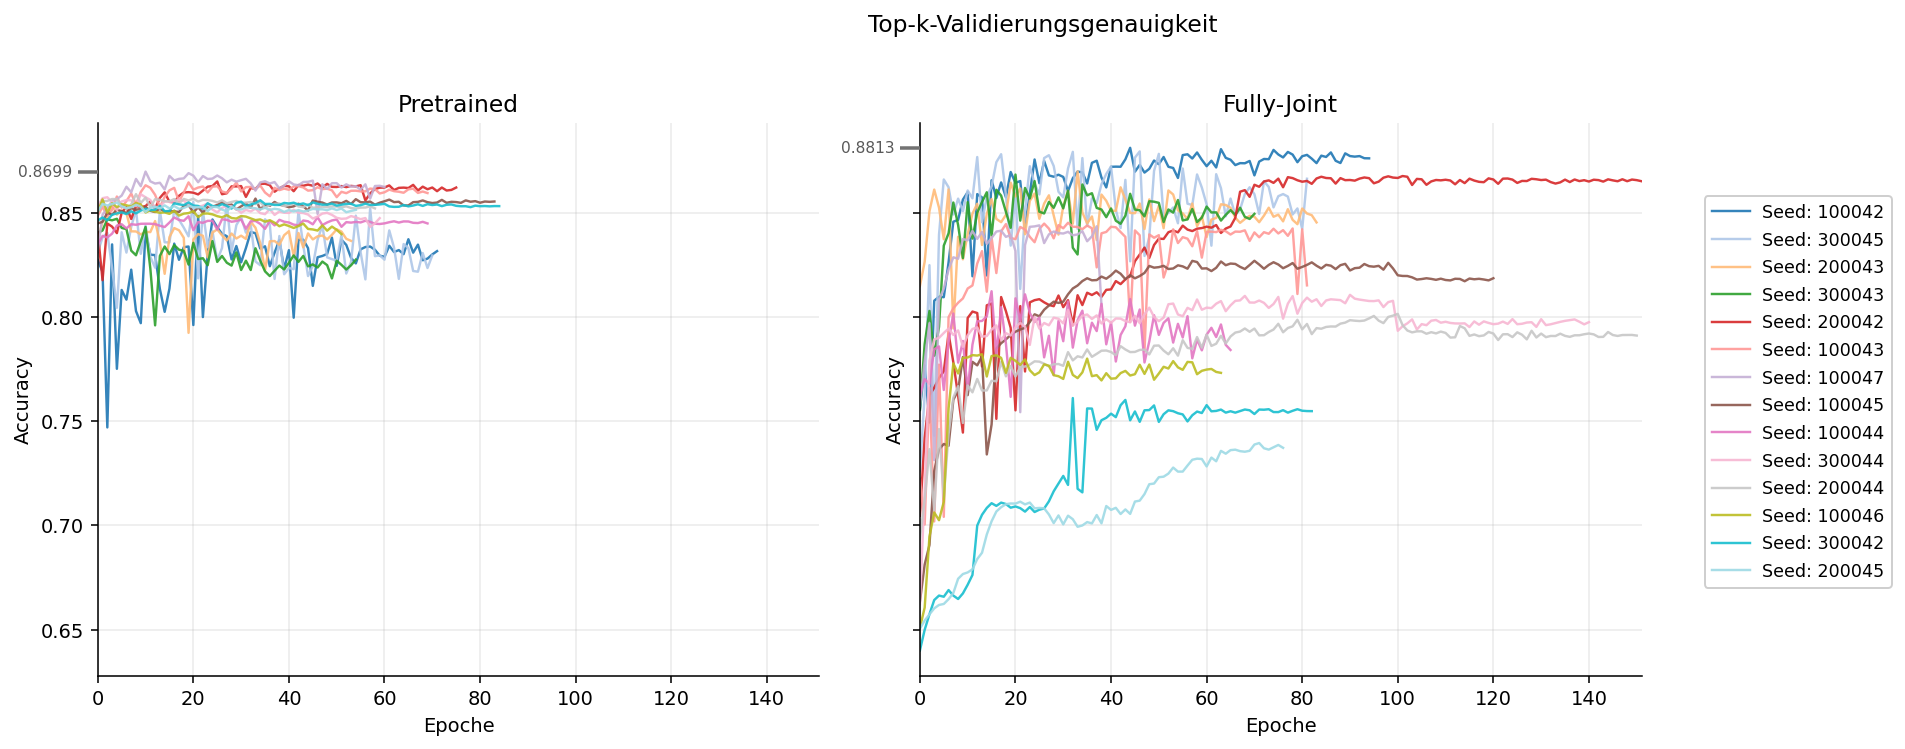

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_paired14_best_val_topk_accuracy.png


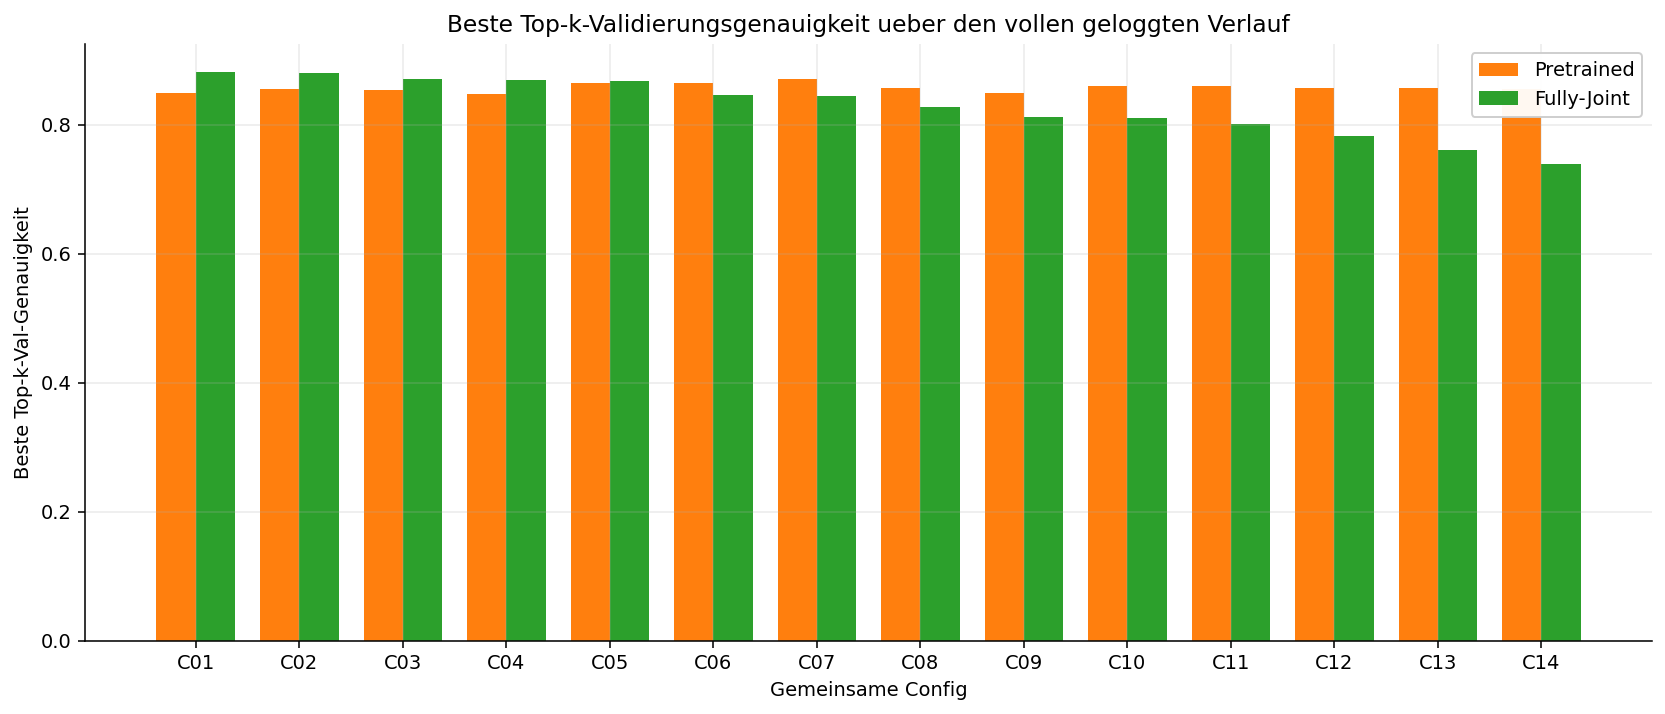

In [6]:
plot_metric_variant_pair(
    "val_topk/accuracy",
    "Accuracy",
    "Top-k-Validierungsgenauigkeit",
    "big_randomsearch_paired14_val_topk_accuracy.png",
    markiere_topk_maximum=True,
)
plot_best_val_topk_paired()


## Training und Hard-Validierung


/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_paired14_train_accuracy.png


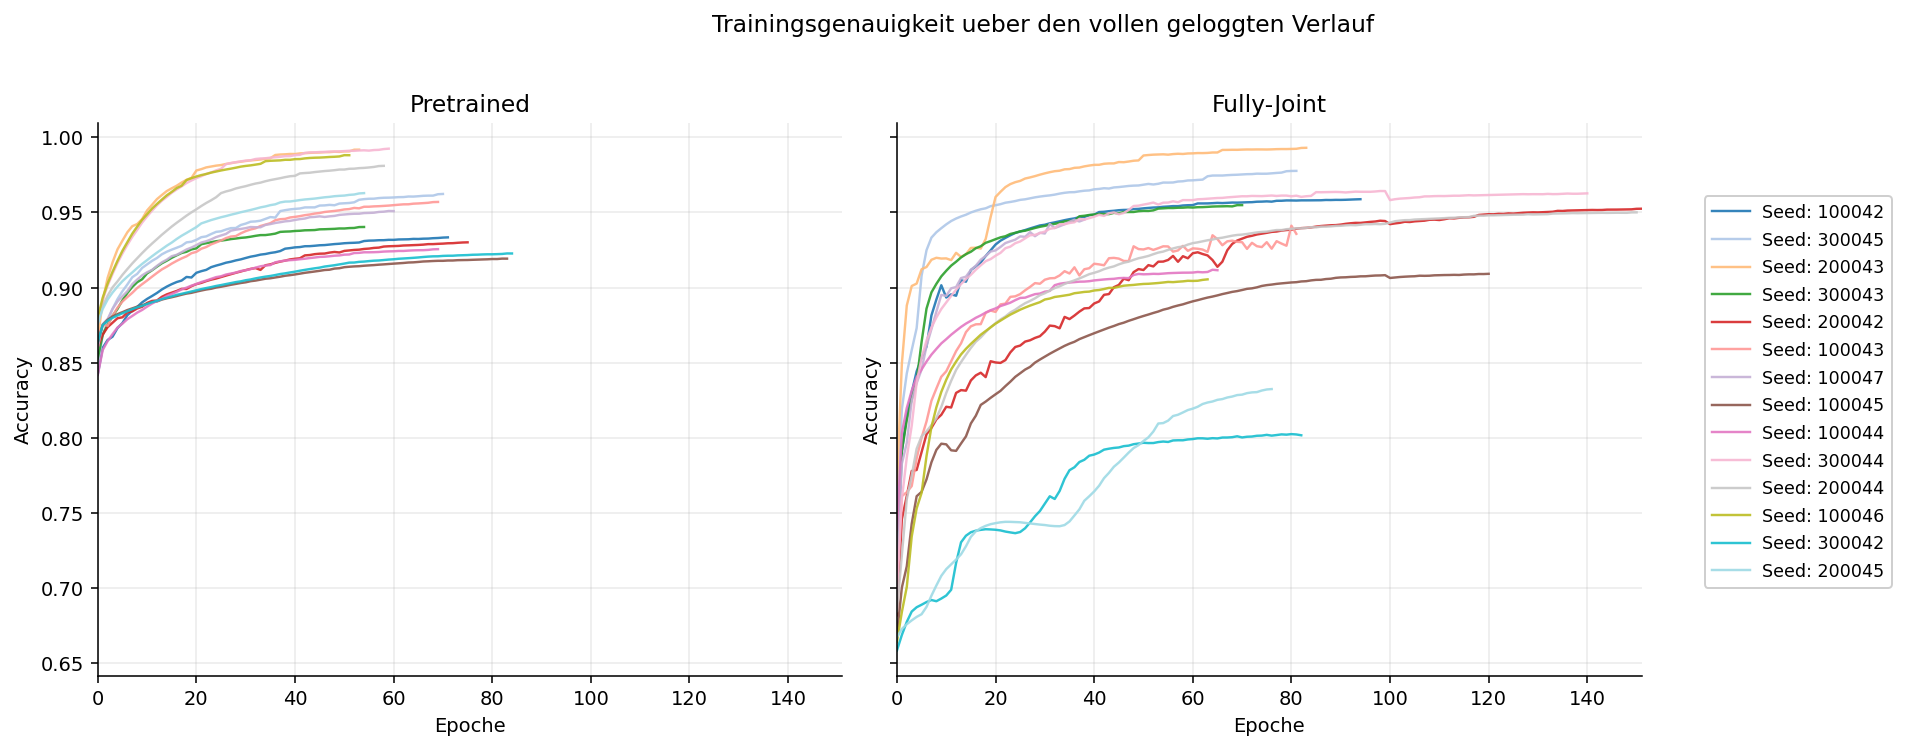

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_paired14_val_hard_accuracy.png


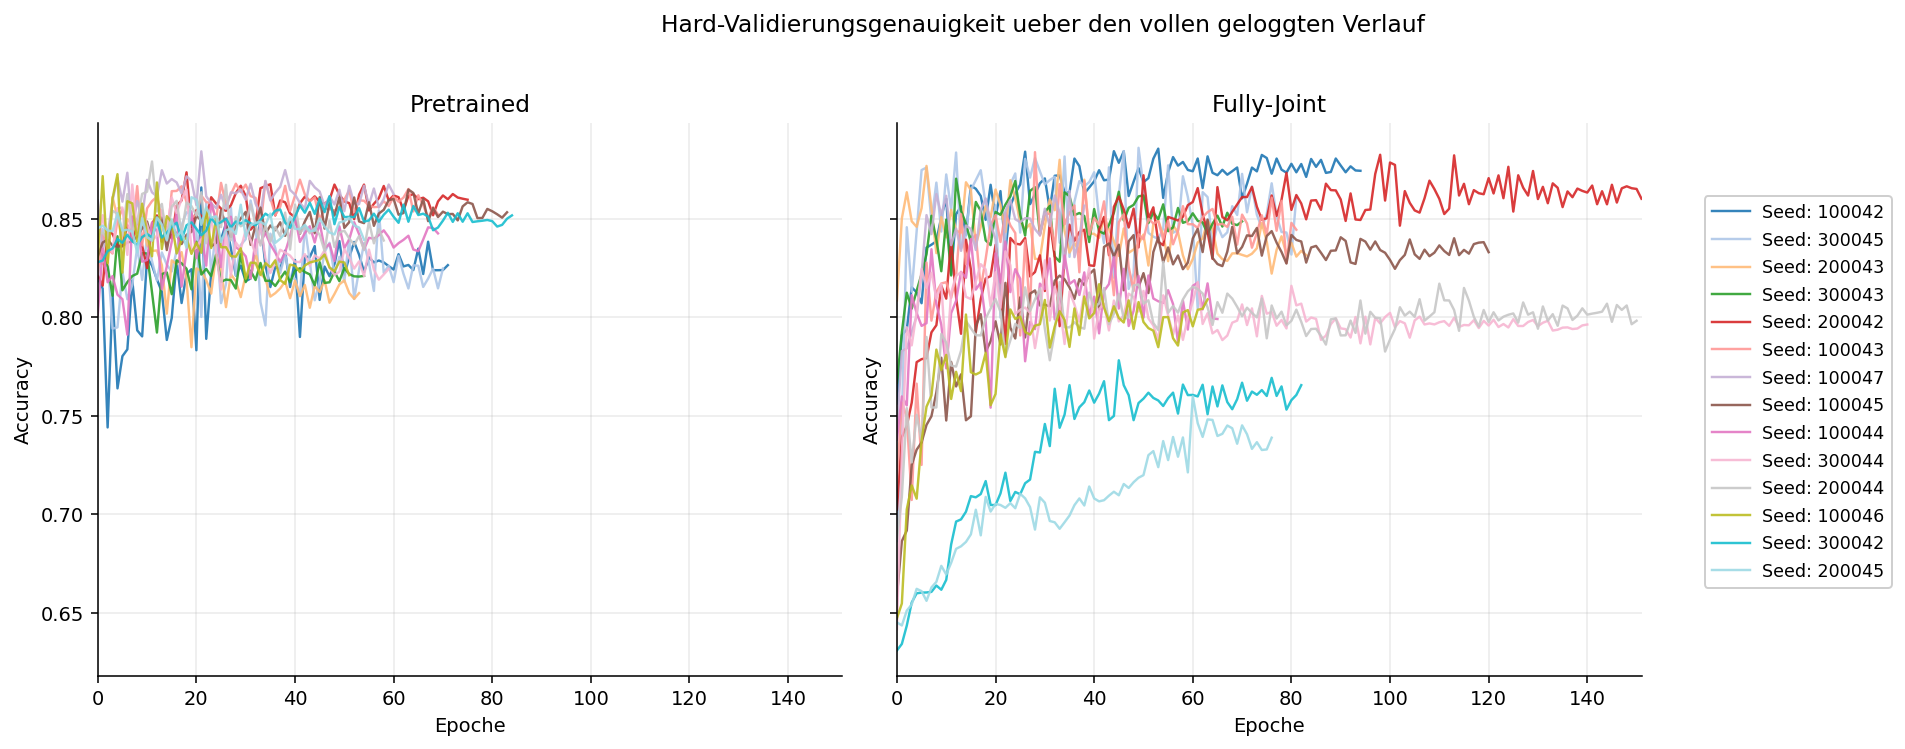

In [7]:
plot_metric_variant_pair(
    "train/accuracy",
    "Accuracy",
    "Trainingsgenauigkeit ueber den vollen geloggten Verlauf",
    "big_randomsearch_paired14_train_accuracy.png",
)
plot_metric_variant_pair(
    "val_hard/accuracy",
    "Accuracy",
    "Hard-Validierungsgenauigkeit ueber den vollen geloggten Verlauf",
    "big_randomsearch_paired14_val_hard_accuracy.png",
)


## Routing-Nutzung


/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_paired14_val_hard_usage.png


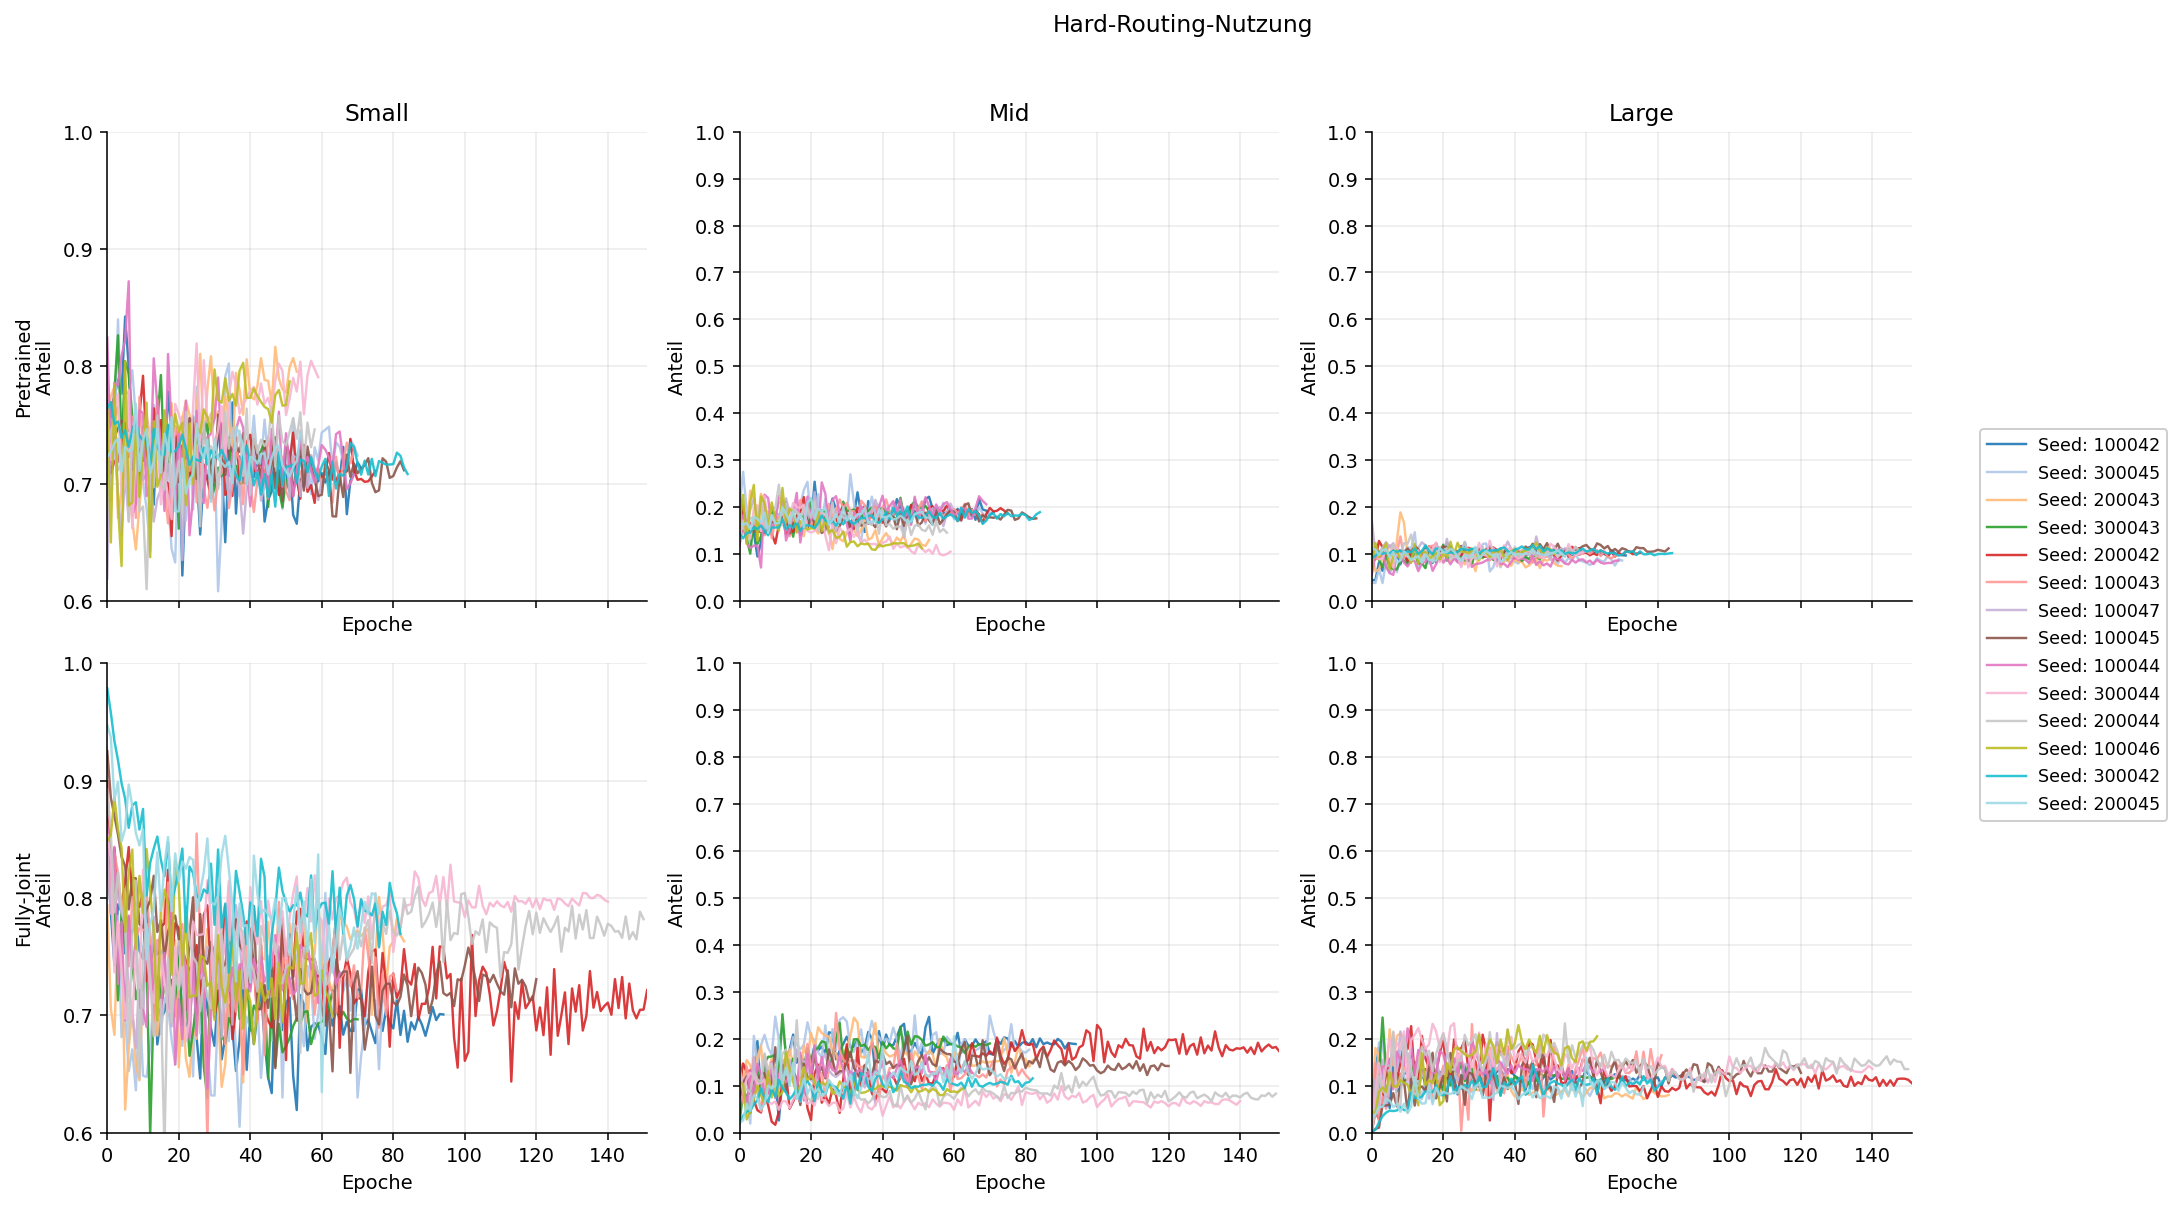

In [8]:
plot_usage_variant_pair()


## Experten und Mittelwert-Uebersicht

Die paarweisen Plots verwenden die gemeinsamen Config-Farben. Die Uebersicht darunter zeigt zusaetzlich die Mittelwerte der beiden Trainingsvarianten ueber dieselben 14 Configs.


/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_paired14_val_expert_accuracy.png


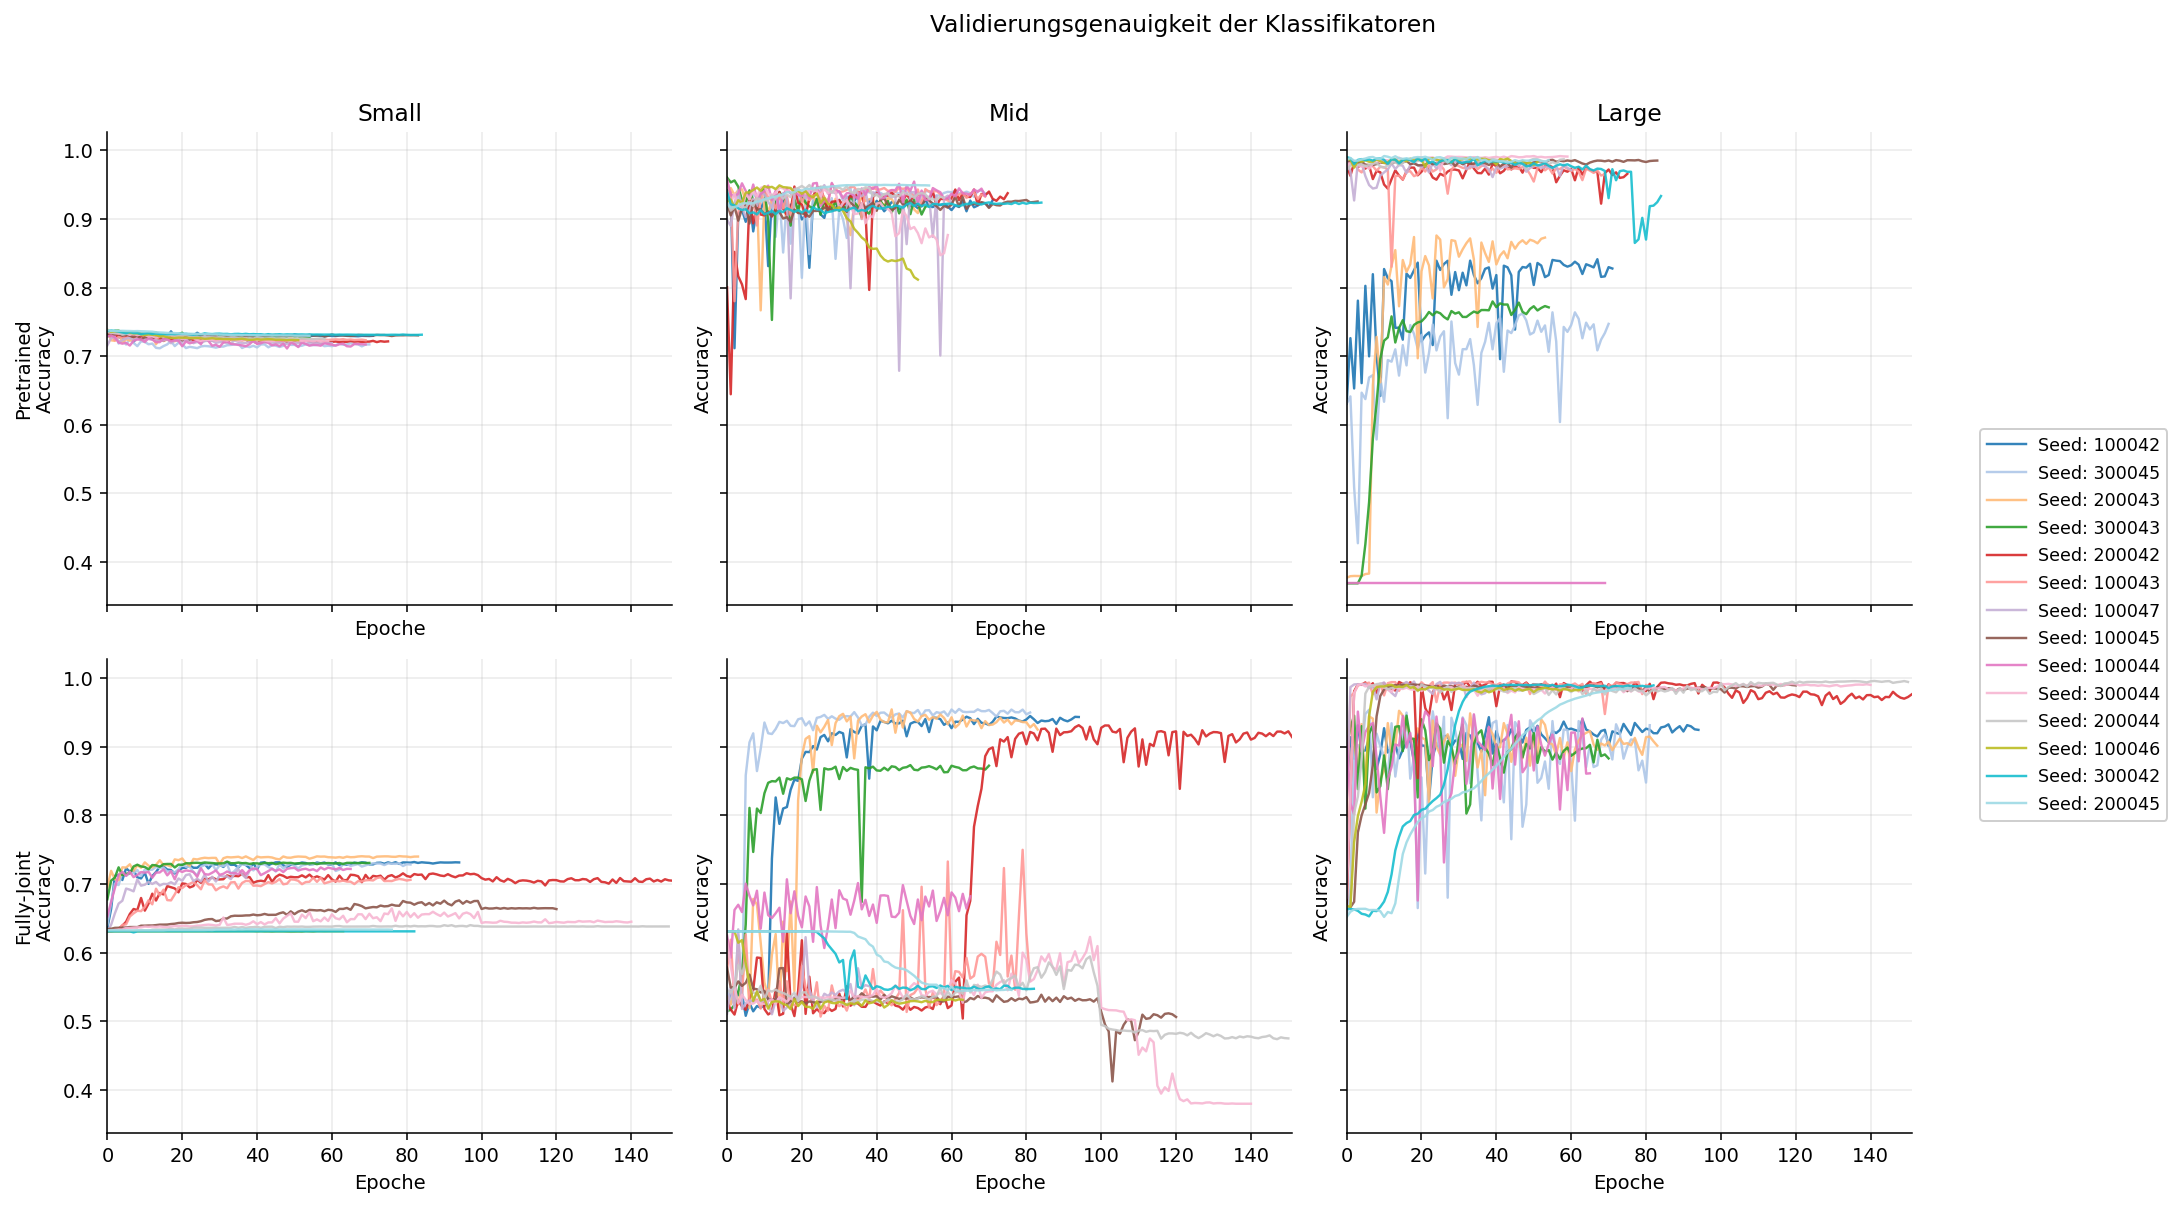

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_paired14_val_topk_accuracy_mean_overview.png


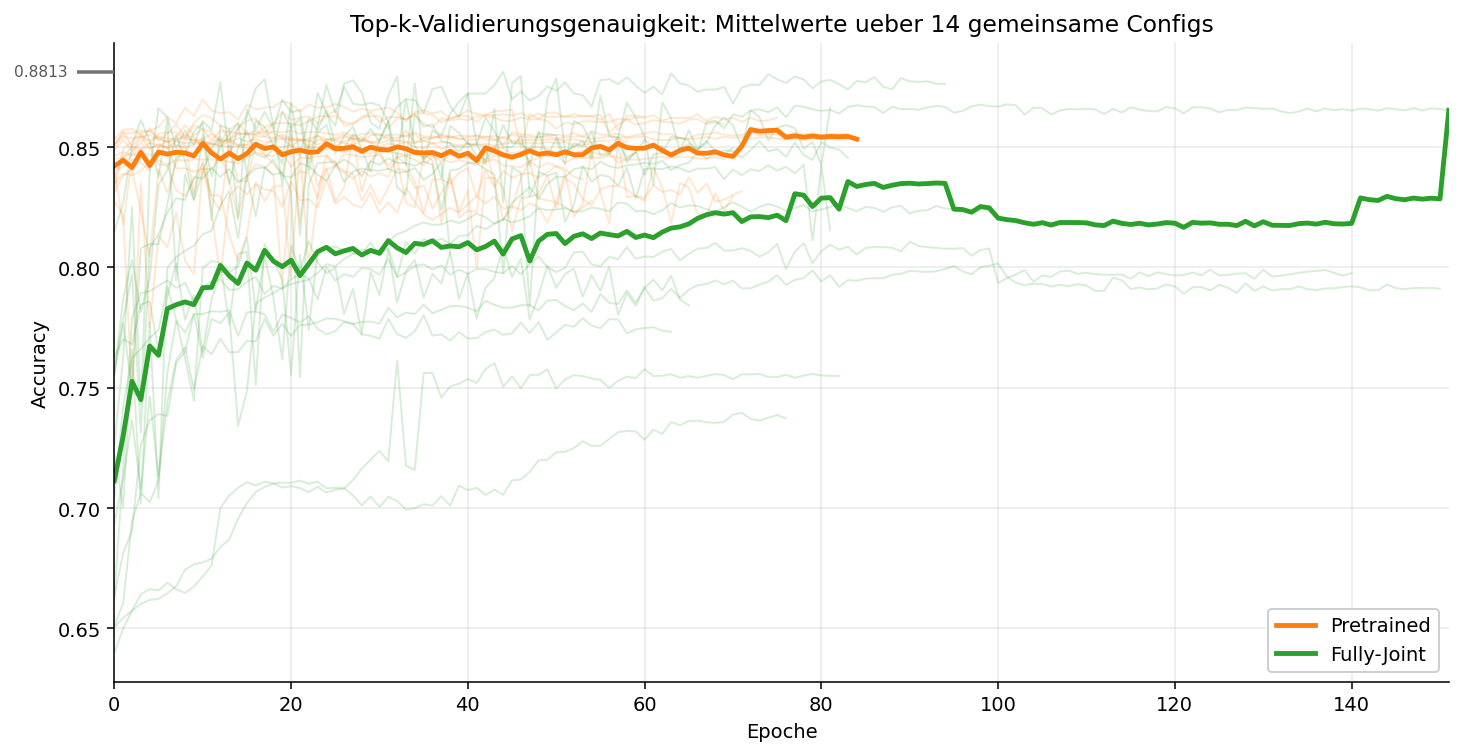

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_paired14_val_budgeted_upper_bound.png


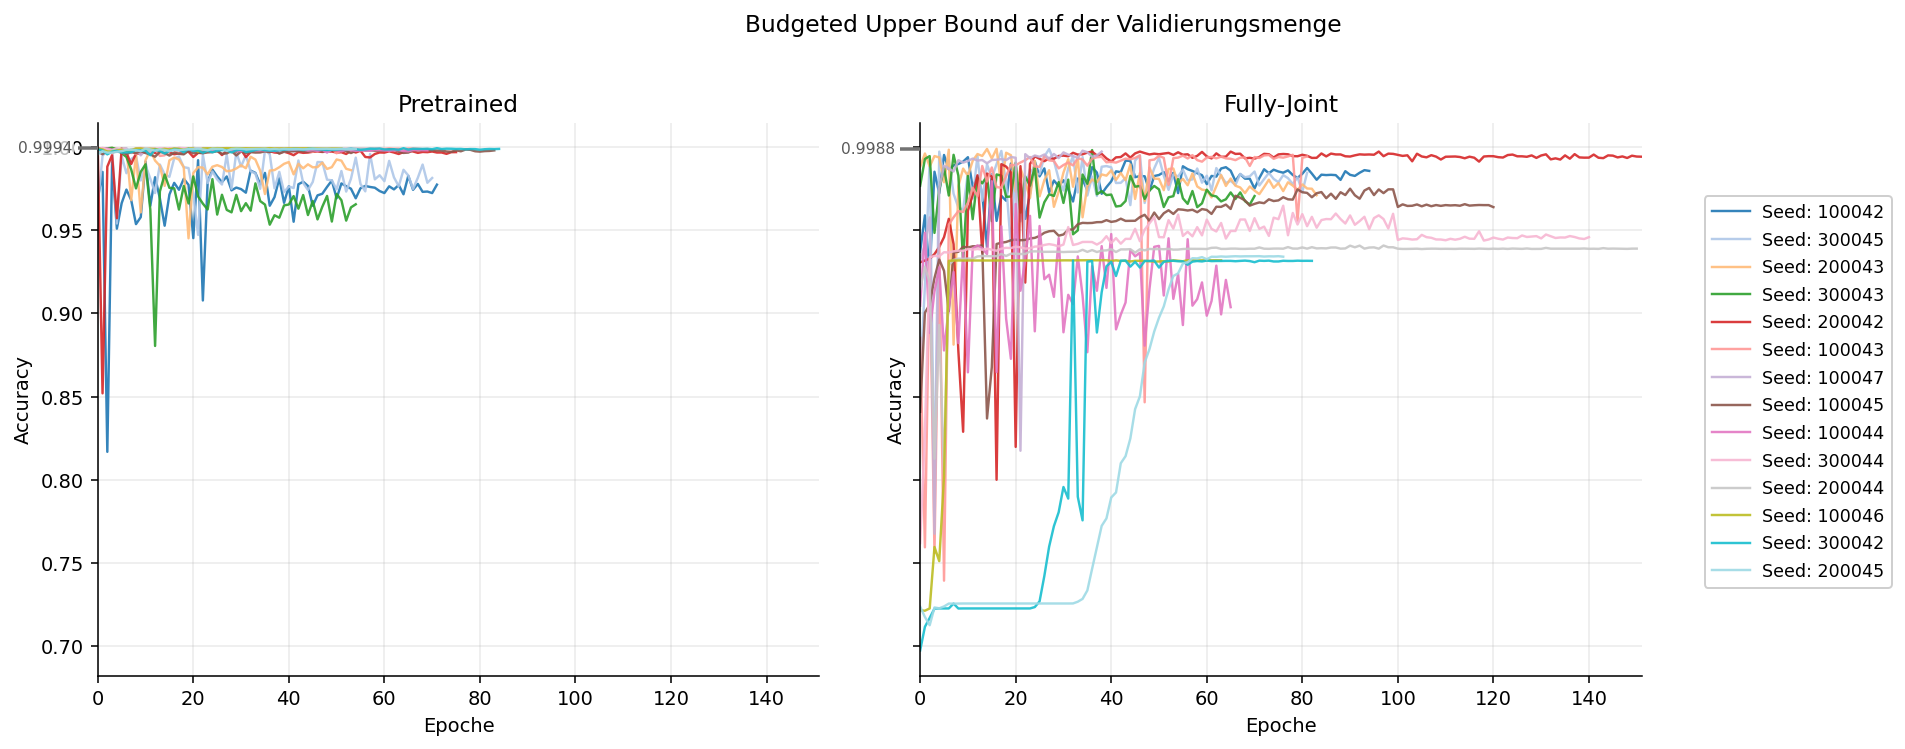

/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/moe/plots/figures_big_randomsearch/big_randomsearch_paired14_val_budgeted_upper_bound_mean_overview.png


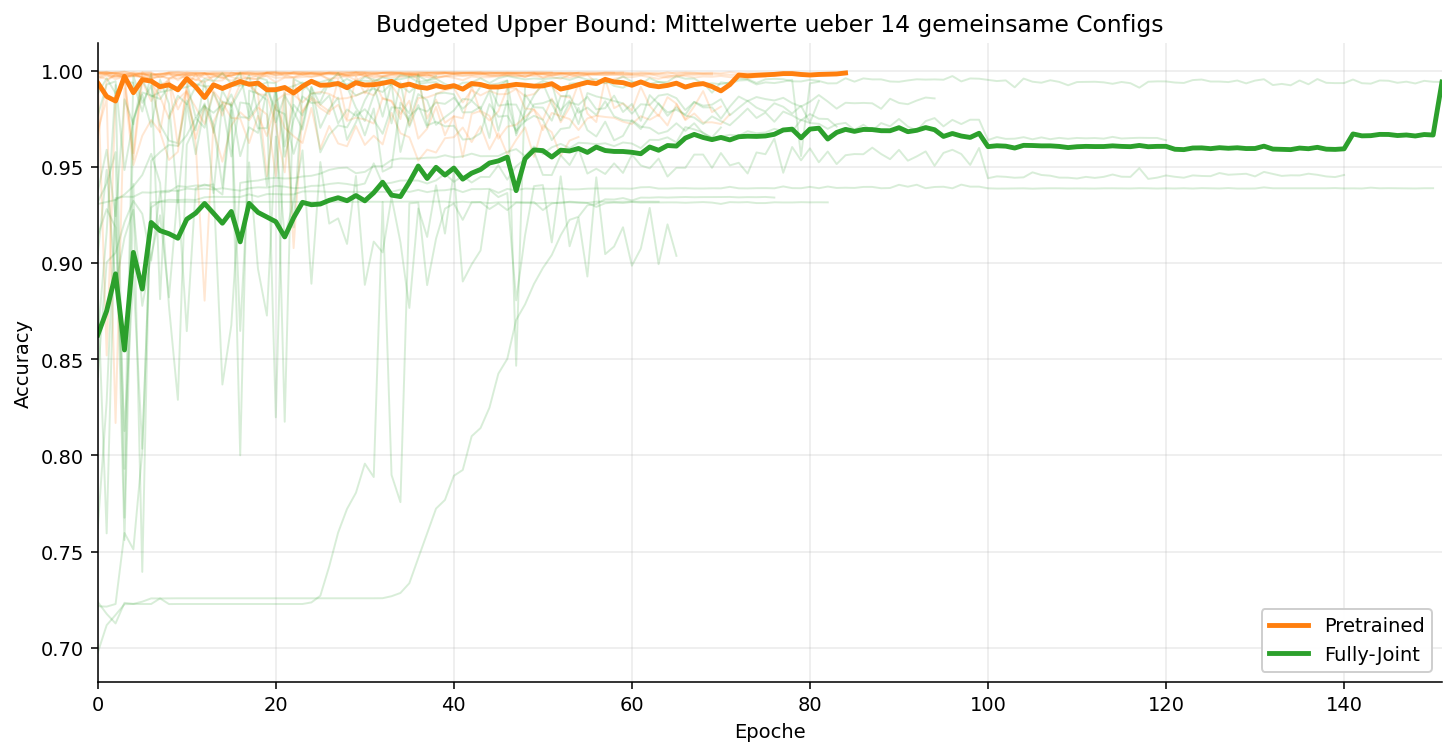

In [9]:
plot_expert_accuracy_variant_pair()
plot_metric_mean_overview(
    "val_topk/accuracy",
    "Accuracy",
    f"Top-k-Validierungsgenauigkeit: Mittelwerte ueber {len(CONFIG_ORDER)} gemeinsame Configs",
    "big_randomsearch_paired14_val_topk_accuracy_mean_overview.png",
)
plot_metric_variant_pair(
    "val_budgeted_upper_bound",
    "Accuracy",
    "Budgeted Upper Bound auf der Validierungsmenge",
    "big_randomsearch_paired14_val_budgeted_upper_bound.png",
    markiere_topk_maximum=True,
)
plot_metric_mean_overview(
    "val_budgeted_upper_bound",
    "Accuracy",
    f"Budgeted Upper Bound: Mittelwerte ueber {len(CONFIG_ORDER)} gemeinsame Configs",
    "big_randomsearch_paired14_val_budgeted_upper_bound_mean_overview.png",
)
